# Applied Machine Learning Experiment: Nonlinear Kernel Regression

**Author:** Dorsa Norouzi  
**Project Type:** Portfolio Demo / Machine Learning Practice  
**Year:** 2026

## Project Overview

This notebook explores nonlinear regression for housing-price prediction using a Gaussian-kernel-based Nadaraya-Watson estimator and a scikit-learn `KernelRidge` model. The experiment shows how the kernel hyperparameter affects prediction behavior and how nonlinear regression can be evaluated on held-out data.

## What This Notebook Demonstrates

- Nonlinear regression with a Gaussian kernel
- Nadaraya-Watson estimator implementation
- Hyperparameter sensitivity analysis using gamma
- Train/test evaluation for regression
- Kernel Ridge Regression with scikit-learn
- Mean-squared-error evaluation


In [ ]:
# Initialization
%matplotlib notebook
%matplotlib inline


In [28]:
import numpy as np

filename = "datasets/ex1data2.txt"
mydata = np.genfromtxt(filename, delimiter=",")

# We have n data-points
n = len(mydata)

# X is a matrix of two column, i.e. an array of n 2-dimensional data-points
X = mydata[:, :2].reshape(n, 2)

# y is the vector of outputs, i.e. an array of n scalar values
y = mydata[:, -1]


print(X[:10])
print(y[:10])


[[2.104e+03 3.000e+00]
 [1.600e+03 3.000e+00]
 [2.400e+03 3.000e+00]
 [1.416e+03 2.000e+00]
 [3.000e+03 4.000e+00]
 [1.985e+03 4.000e+00]
 [1.534e+03 3.000e+00]
 [1.427e+03 3.000e+00]
 [1.380e+03 3.000e+00]
 [1.494e+03 3.000e+00]]
[399900. 329900. 369000. 232000. 539900. 299900. 314900. 198999. 212000.
 242500.]


## 1. Gaussian Kernel Regression

The Nadaraya-Watson estimator predicts a new value by weighting training examples according to their Gaussian-kernel similarity to the test point. The gamma parameter controls how strongly distance affects similarity.

$$k(u,v) = e^{-\gamma \lVert u-v \rVert^2}$$


In [29]:
import math
import numpy as np


def gaussian_kernel(u, v, gamma):
    distance = np.linalg.norm(u - v)
    return math.exp(-gamma * (distance ** 2))




def h(x, X, y, gamma):
    # An array containing the similarity between x and all the others data-points in X :
    similarities = np.array([ gaussian_kernel(x, xi, gamma) for xi in X ])
    denominator = np.sum(similarities)
    if denominator == 0:
        return h(x, X, y, gamma * 0.1)
    numerator = np.sum(similarities * y)
    return numerator / denominator



gamma = 0.00005
x = np.array([1650, 3])
prediction = h(x,X,y,gamma)
print("The prediction on x is:", prediction)


The prediction on x is: 303395.90573947056


## 2. Gamma Sensitivity

The prediction for the same house is evaluated across different gamma values to show how the kernel width affects the output.


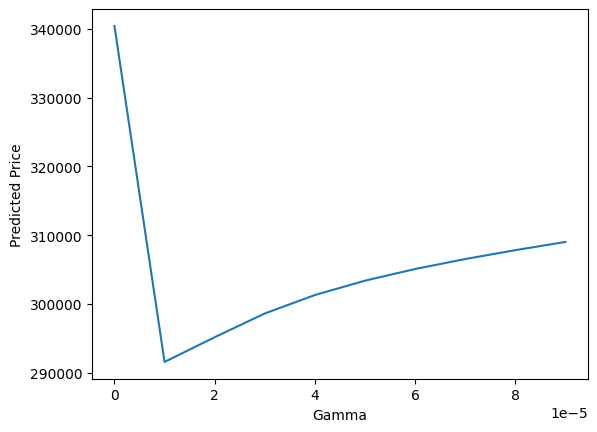

In [30]:
import matplotlib.pylab as plt



x = np.array([1650, 3])
gammas_list = np.arange(1e-10, 10e-5, 1e-5)
predictions = []

for gamma in gammas_list:
    prediction = h(x, X, y, gamma)
    predictions.append(prediction)

fig, ax = plt.subplots()
ax.plot(gammas_list, predictions, label="Predicted price")
ax.set_xlabel("Gamma")
ax.set_ylabel("Predicted Price")
plt.show()


## 3. Train/Test Evaluation

The dataset is split into training and testing portions. Predictions on the test set are compared visually against the true house prices.


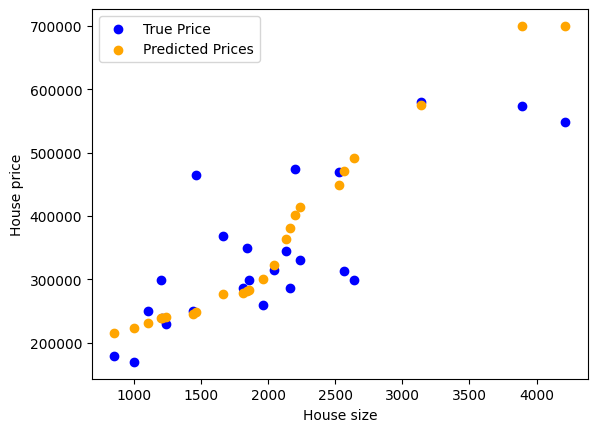

In [31]:
gamma = 0.00005
n = len(X)

# The training part:
X_train = X[ : n//2] # First half of the dataset
y_train = y[ : n//2] # Outputs corresponding to the first half

# The testing part:
X_test = X[n//2 : ] # Second half of the dataset
y_test = y[n//2 : ] # Outputs corresponding to the second half



y_pred = []
for x in X_test:
    prediction = h(x,X_train,y_train,gamma)
    y_pred.append(prediction)



fig, ax = plt.subplots()
ax.scatter(X_test[:,0], y_test, color = "blue", label = "True Price")
ax.scatter(X_test[:,0], y_pred, color = "orange", label="Predicted Prices")

ax.set_xlabel("House size")
ax.set_ylabel("House price")

ax.legend()
plt.show()


## 4. Nonlinear Regression with scikit-learn

The same nonlinear regression idea is also demonstrated with scikit-learn using a train/test split.


In [32]:
from sklearn.model_selection import train_test_split

# Keep 30% of the data for test (i.e. test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print("Full data:", X.shape, y.shape)
print("Train data:", X_train.shape, y_train.shape)
print("Test data:", X_test.shape, y_test.shape)


Full data: (47, 2) (47,)
Train data: (32, 2) (32,)
Test data: (15, 2) (15,)


## 5. Feature Scaling

A `StandardScaler` is used before fitting the kernel-based model, which helps keep the feature magnitudes consistent.


In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)

X_train_normalized = scaler.transform(X_train) # Scale the training data
X_test_normalized = scaler.transform(X_test) # Scale the test data


## 6. Kernel Ridge Regression

A scikit-learn `KernelRidge` model with an RBF kernel is trained and evaluated using mean squared error.


In [34]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error

reg = KernelRidge(kernel='rbf', gamma=0.05).fit(X_train_normalized, y_train) # Training
y_pred = reg.predict(X_test_normalized) # Predicting

mse = mean_squared_error(y_test, y_pred) # Same as: ((y_test - y_pred)**2).mean()
print("The MSE on the test data is:", mse)


The MSE on the test data is: 6839677607.54494


## 7. Summary

This experiment demonstrates how nonlinear regression can be implemented with a custom Gaussian-kernel estimator and compared with a library-based kernel regression workflow.
